# Setup

In [33]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

import os

In [34]:
import logging
import sys
sys.path.append("../")

from utils.seed_all import seed_all
from metrics.factory import MetricsFactory
from modeling.structure.factory import ModelingStructureFactory

DEFAULT_SEED = 10
seed_all(DEFAULT_SEED)

formatter = logging.Formatter('%(asctime)s | %(levelname)s | %(message)s')
logger = logging.getLogger('sequence_log')
logger.setLevel(logging.INFO)

console_handler = logging.StreamHandler()
console_handler.setFormatter(formatter)
logger.addHandler(console_handler)

In [56]:
def plot_img_loss(img_loss, min=None, max=None, targets=[], title='Mean Image Loss Map'):
    plt.figure(figsize=(10, 8))  # Adjust size as needed

    plt.imshow(img_loss, cmap=shap.plots.colors.red_blue, aspect='auto', interpolation='nearest', vmin=min, vmax=max)

    n_cols = img_loss.shape[1]

    # --- protocol field layout ---
    # field_spans = [
    #     ("start", 2),
    #     ("seq_num", 1),
    #     ("t_uncertain", 1),
    #     ("stream_id", 8),
    #     ("timestamp", 1),
    #     ("gateway", 1),
    #     ("length", 1),
    #     ("CIP", 1),
    #     ("CIP", 1),
    #     ("Source ID", 1),
    #     ("Data block size", 1),
    #     ("CIP", 1),
    #     ("Data block continuity", 1),
    #     ("CIP", 1),
    #     ("CIP", 1),
    # ]

    field_spans = [
        ("start", 16),
        ("message_length", 2),
        ("middle", 4),
        ("correction_ns", 6),
        ("correction_ns_sub", 2),
        ("type", 4),
        ("clock_id", 8),
        ("source_port_id", 2),
        ("sequence_id", 2),
        ("origin_timestamp_s", 8),
        ("origin_timestamp_n", 4),
    ]

    field_ticks = []
    field_labels = []
    cursor = 0

    for name, width in field_spans:
        center = cursor + (width / 2)
        field_ticks.append(center)
        field_labels.append(name)
        cursor += width

    payload_start = cursor

    # --- payload ticks ---
    n_payload_ticks = 0 # 7
    payload_ticks = np.linspace(payload_start, n_cols - 1,
                                n_payload_ticks, dtype=int)
    payload_labels = [f"P[{i - payload_start}]" for i in payload_ticks]

    # --- final ticks ---
    xticks = field_ticks + list(payload_ticks)
    xlabels = field_labels + payload_labels

    plt.xticks(xticks, xlabels, rotation=45, ha="right")

    plt.colorbar(label='SHAP value')

    # Draw horizontal lines for rows with label == 1
    for i, lbl in enumerate(targets):
        if lbl != 'Normal':
            plt.axhline(i, color='black', linewidth=1.5, alpha=1)  # top edge
            # plt.axhline(i + 0.5, color='red', linewidth=1.5, alpha=0.1)  # bottom edge


    plt.xlabel("Feature")
    plt.ylabel("Window Index")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    plt.close()

In [36]:
def load_data(base_file, phase='test'):
    with open(f'{base_file}/config.yaml', "r") as f:
        config = yaml.safe_load(f)
    path = f'{base_file}/{phase}_labels_predictions.pt'
    cache = torch.load(path, weights_only=False)
    y_true, y_out = cache['y_true'], cache['y_scores']
    y_pred, y_scores = y_out
    y_pred = np.array(y_pred)
    y_scores = np.array(y_scores)
    y_true['scores'] = np.array(y_scores).mean(axis=(1, 2))

    return y_true, y_pred, y_scores, config

In [37]:
def load_x(path: str, load_subset = None) -> tuple[np.ndarray, pd.DataFrame]:
        
        files = [f for f in os.listdir(path)]
        files.sort()
        all_X, all_y = [], []

        for file in files:
            cache = torch.load(f"{path}/{file}", weights_only=False)
            all_X.append(cache['X'])
            all_y.append(cache['y'])

        X = np.concatenate(all_X, axis=0)
        y = pd.concat(all_y, axis=0).reset_index(drop=True)

        if load_subset is not None:

            indices = np.random.choice(len(X), size=int(load_subset*len(X)), replace=False)
            X = X[indices]
            y = y.iloc[indices].reset_index(drop=True)

        return X, y

# Confidence scores

In [38]:
path = '../runs/our_PTP_tcn_pred_TOWIDS_20260207_175452'

In [39]:
import yaml
with open(path + '/config.yaml', "r") as f:
    config = yaml.safe_load(f) or {}


threshold = pd.read_json(f'{path}/train_metrics.json')['optimal_threshold'].values[0]

In [40]:
y_true, y_pred, y_scores, config = load_data(path, phase='test')
y_true_benign = y_true[y_true["label"] == 'Normal']

In [145]:
scores = y_true['scores']
U = np.abs(scores - threshold)

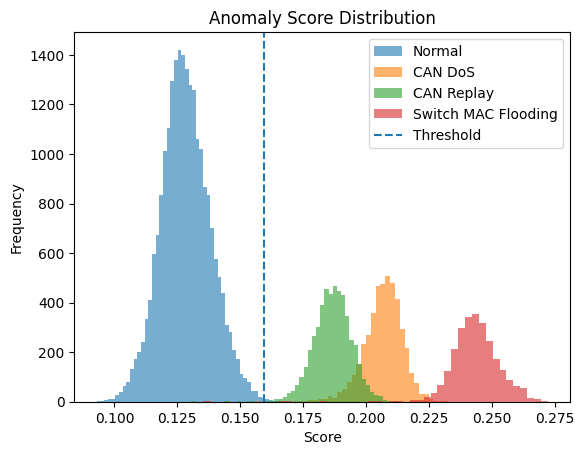

In [153]:
plt.figure()
plt.hist(scores[y_true['label'] == 'Normal'], bins=50, alpha=0.6, label="Normal")
plt.hist(scores[y_true['label'] == 'CAN DoS'], bins=50, alpha=0.6, label="CAN DoS")
plt.hist(scores[y_true['label'] == 'CAN Replay'], bins=50, alpha=0.6, label="CAN Replay")
plt.hist(scores[y_true['label'] == 'Switch MAC Flooding'], bins=50, alpha=0.6, label="Switch MAC Flooding")
# plt.hist(scores[y_true['label'] == 'Frame Injection'], bins=50, alpha=0.6, label="Frame Injection")
plt.axvline(threshold, linestyle="--", label="Threshold")
plt.legend()
plt.title("Anomaly Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

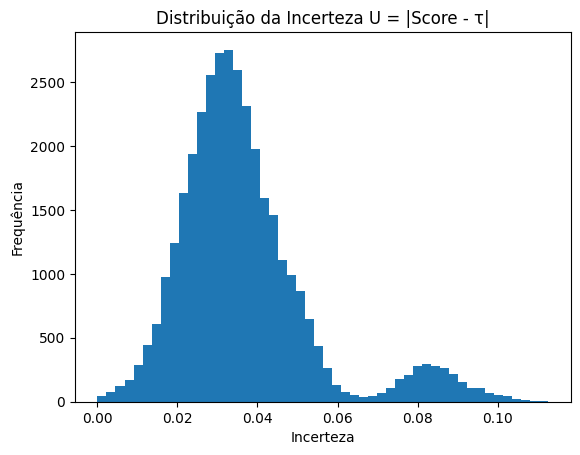

In [154]:
plt.figure()
plt.hist(U, bins=50)
plt.title("Distribuição da Incerteza U = |Score - τ|")
plt.xlabel("Incerteza")
plt.ylabel("Frequência")
plt.show()

In [155]:
y_true['pred'] = (scores > threshold).astype(int)
y_true['class'] = y_true['label'].apply(lambda x: 0 if x == 'Normal' else 1).astype(int)

In [156]:
errors = (y_true['pred'] != y_true['class']).astype(int)

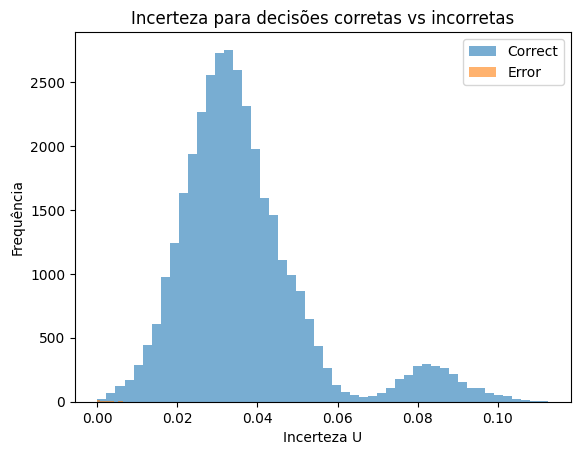

In [157]:
U_correct = U[errors == 0]
U_error   = U[errors == 1]

plt.figure()
plt.hist(U_correct, bins=50, alpha=0.6, label="Correct")
plt.hist(U_error, bins=50, alpha=0.6, label="Error")
plt.legend()
plt.title("Incerteza para decisões corretas vs incorretas")
plt.xlabel("Incerteza U")
plt.ylabel("Frequência")
plt.show()

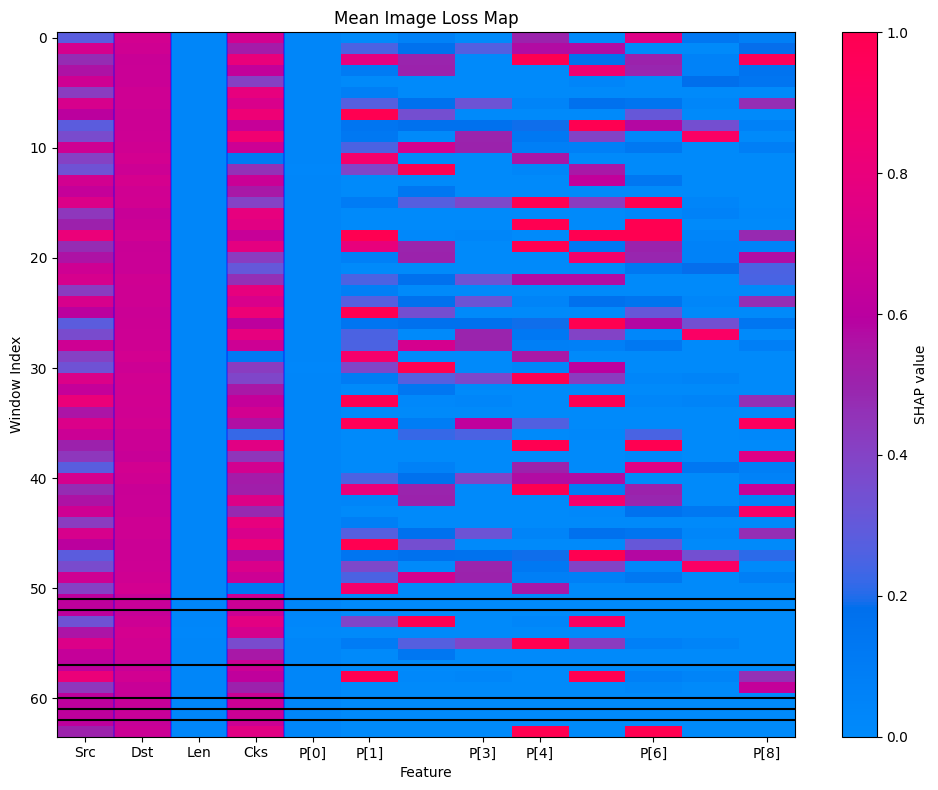

In [215]:
plot_img_loss(X_test[y_true[y_true['label'] == 'CAN DoS'].index][:, :, :][0], 
              targets=y_true[y_true['label'] == 'CAN DoS']['desc_windows'].iloc[0], )

In [218]:
X_test[y_true[y_true['label'] == 'CAN DoS'].index][:, :][0][-2]

array([0.6117647 , 0.64705884, 0.03333334, 0.6647059 , 0.03137255,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        ], dtype=float32)

In [158]:
mean_normal = y_true[y_true['class'] == 0]['scores'].mean()
std_normal  = y_true[y_true['class'] == 0]['scores'].std()

k = 1
tau1 = threshold - k * std_normal
tau2 = threshold + k * std_normal

In [159]:
zones = np.zeros_like(scores, dtype=int)
# 0: normal confiante, 1: incerta, 2: anômala confiante

zones[scores < tau1] = 0
zones[(scores >= tau1) & (scores <= tau2)] = 1
zones[scores > tau2] = 2

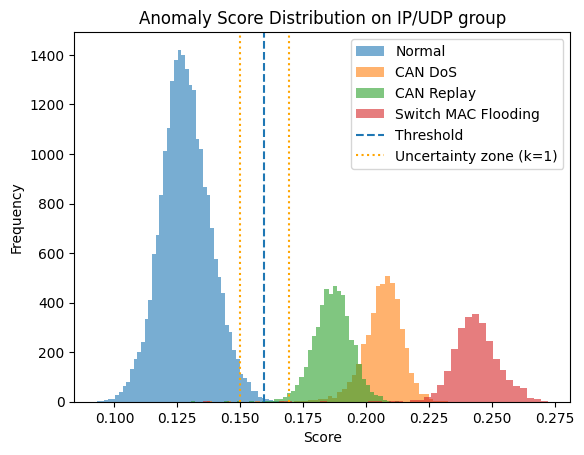

In [181]:
plt.figure()
plt.hist(scores[y_true['label'] == 'Normal'], bins=50, alpha=0.6, label="Normal")
plt.hist(scores[y_true['label'] == 'CAN DoS'], bins=50, alpha=0.6, label="CAN DoS")
plt.hist(scores[y_true['label'] == 'CAN Replay'], bins=50, alpha=0.6, label="CAN Replay")
plt.hist(scores[y_true['label'] == 'Switch MAC Flooding'], bins=50, alpha=0.6, label="Switch MAC Flooding")
# plt.hist(scores[y_true['label'] == 'Frame Injection'], bins=50, alpha=0.6, label="Frame Injection")
plt.axvline(threshold, linestyle="--", label="Threshold")
plt.axvline(tau1, linestyle=":", c='orange', label="Uncertainty zone (k=1)")
plt.axvline(tau2, linestyle=":", c='orange')
plt.legend()
plt.title("Anomaly Score Distribution on IP/UDP group")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

In [191]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Histogram(
    x=scores[y_true['label'] == 'Normal'],
    nbinsx=50,
    opacity=0.6,
    name='Normal'
))

fig.add_trace(go.Histogram(
    x=scores[y_true['label'] == 'CAN DoS'],
    nbinsx=50,
    opacity=0.6,
    name='CAN DoS'
))

fig.add_trace(go.Histogram(
    x=scores[y_true['label'] == 'CAN Replay'],
    nbinsx=50,
    opacity=0.6,
    name='CAN Replay'
))

fig.add_trace(go.Histogram(
    x=scores[y_true['label'] == 'Switch MAC Flooding'],
    nbinsx=50,
    opacity=0.6,
    name='Switch MAC Flooding'
))

# Vertical lines (thresholds)
fig.add_vline(
    x=threshold,
    line_dash="dash",
    annotation_text="Threshold",
    annotation_position="top"
)

fig.add_vline(
    x=tau1,
    line_dash="dot",
    annotation_text="T1",
    annotation_position="top"
)

fig.add_vline(
    x=tau2,
    line_dash="dot",
    annotation_text="T2",
    annotation_position="top"
)

fig.update_layout(
    title="Anomaly Score Distribution on IP/UDP group",
    xaxis_title="Score",
    yaxis_title="Frequency",
    barmode="overlay",   # equivalent to overlapping histograms
    legend_title="Label"
)
fig.update_layout(
    width=1050,   # pixels
    height=750,   # pixels
    margin=dict(l=80, r=40, t=80, b=70),
)

fig.show()


In [475]:
import pandas as pd

df = pd.DataFrame({
    "zone": zones,
    "error": errors
})

zone_stats = df.groupby("zone").agg(
    total=("error", "count"),
    errors=("error", "sum")
)
zone_stats["error_rate"] = zone_stats["errors"] / zone_stats["total"]
zone_stats

,total,errors,error_rate
zone,,,
0,19954,4,0.000200
1,3582,41,0.011446
2,11363,0,0.000000


In [380]:
y_true[(y_true['scores'] > tau1) & (y_true['scores'] < tau2)]['label'].value_counts()

label
Normal                 440
CAN Replay              71
CAN DoS                  3
Switch MAC Flooding      2
Name: count, dtype: int64

In [381]:
y_true[y_true['scores'] > tau2]['label'].value_counts()

label
CAN Replay             5003
CAN DoS                4508
Switch MAC Flooding    2574
Name: count, dtype: int64

In [382]:
y_true[y_true['scores'] < tau1]['label'].value_counts()

label
Normal                 22292
CAN DoS                    2
CAN Replay                 2
Switch MAC Flooding        2
Name: count, dtype: int64

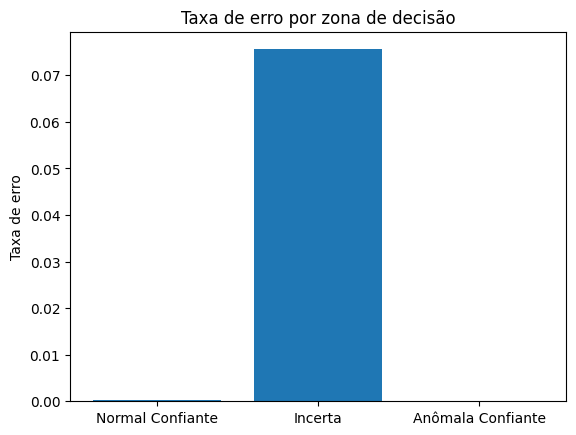

In [383]:
zone_names = ["Normal Confiante", "Incerta", "Anômala Confiante"]

plt.figure()
plt.bar(zone_names, zone_stats["error_rate"])
plt.title("Taxa de erro por zona de decisão")
plt.ylabel("Taxa de erro")
plt.show()

In [250]:
from scipy.stats import pointbiserialr

corr, p_value = pointbiserialr(errors, U)
print("Correlação incerteza–erro:", corr)
print("p-value:", p_value)

Correlação incerteza–erro: -0.06609360156065752
p-value: 4.290861424352899e-35


# Global Metrics

In [113]:
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support


def get_overall_metrics(y_true, y_scores):
    tn, fp, fn, tp = confusion_matrix(y_true, y_scores).ravel()
    acc = (tp+tn)/(tp+tn+fp+fn)
    tpr = tp/(tp+fn)
    fpr = fp/(fp+tn)
    precision = tp/(tp+fp)
    f1 = (2*tpr*precision)/(tpr+precision)
    return {'Accuracy':acc,'TPR':tpr,'FPR':fpr,'Precision':precision,'F1-score':f1}

In [137]:
with open(f'../runs/aero_AEID_20260128_110602/config.yaml', "r") as f:
    config = yaml.safe_load(f)
path = f'../runs/aero_AEID_20260128_110602/test_labels_predictions.pt'
cache = torch.load(path, weights_only=False)
y_true, y_out = cache['y_true'], cache['y_scores']
y_pred, y_scores = y_out
y_pred = np.array(y_pred)
y_true['scores'] = y_scores

In [139]:
threshold = pd.read_json(f'../runs/aero_AEID_20260128_110602/train_metrics.json')['optimal_threshold'].values[0]
y_true['y_pred'] = y_true['scores'] > threshold
y_true['label'] = y_true['label'].apply(lambda x: 0 if x == 'Normal' else 1)
y_true['y_pred'] = y_true['scores'] > threshold

In [141]:
tn, fp, fn, tp = confusion_matrix(y_true['label'], y_true['y_pred']).ravel()
tn, fp, fn, tp

(np.int64(1955), np.int64(876), np.int64(1957), np.int64(55753))

In [155]:
tp/(tp+tn), fn/(fn+fp)

(np.float64(0.9661225480002773), np.float64(0.6907871514295799))

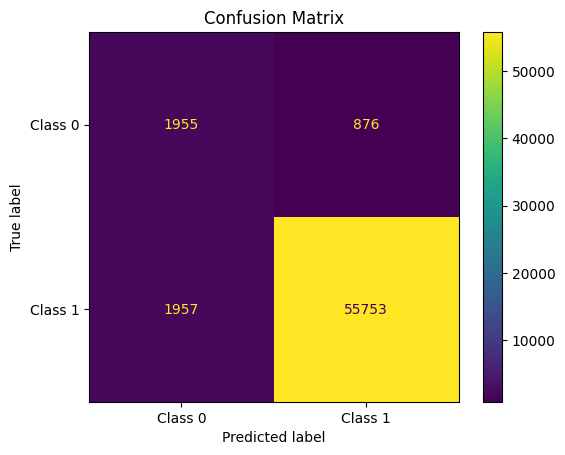

In [143]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true['label'], y_true['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap='viridis')
plt.title('Confusion Matrix')
plt.show()

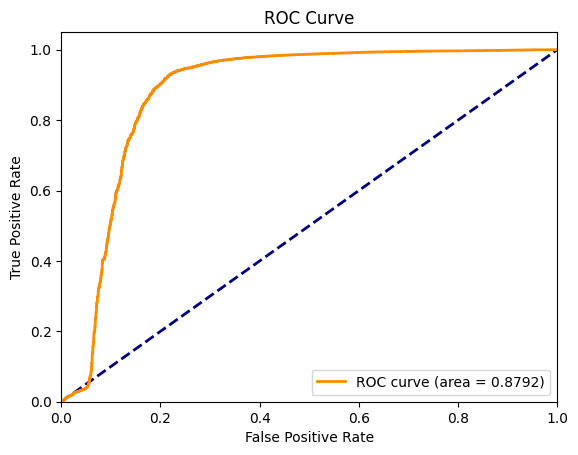

In [142]:
from sklearn.metrics import roc_auc_score, roc_curve


fpr, tpr, thresholds = roc_curve(y_true['label'], y_true['scores'])
aucroc = roc_auc_score(y_true['label'], y_true['scores'])
plt.figure()
plt.plot([0, 2], [0, 2], color="navy", lw=2, linestyle="--")
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {aucroc:.4f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()
plt.close()

In [144]:
precision_recall_fscore_support(y_true['label'], y_true['y_pred'], average='weighted')

(0.9618614529942928, 0.9532052658528931, 0.9567349940114662, None)

In [158]:
path = '../runs/tcn_pred_TOWIDS_20260127_171835'
y_true_avtp, y_pred, y_scores, config = load_data(path, phase='test')
threshold = pd.read_json(f'{path}/train_metrics.json')['optimal_threshold'].values[0]
y_true_avtp['y_pred'] = y_true_avtp['scores'] > threshold
y_true_avtp['label'] = y_true_avtp['label'].apply(lambda x: 0 if x == 'Normal' else 1)
y_true_avtp['y_pred'] = y_true_avtp['scores'] > threshold
del y_pred, y_scores, config

In [159]:
path = '../runs/our_PTP'
y_true_ptp, y_pred, y_scores, config = load_data(path, phase='test')
c = pd.read_json(f'{path}/train_metrics.json')['optimal_threshold'].values[0]
y_true_ptp['label'] = y_true_ptp['label'].apply(lambda x: 0 if x == 'Normal' else 1)
y_true_ptp['y_pred'] = y_true_ptp['scores'] > threshold
del y_pred, y_scores, config

In [160]:
path = '../runs/our_UDP'
y_true_udp, y_pred, y_scores, config = load_data(path, phase='test')
threshold = pd.read_json(f'{path}/train_metrics.json')['optimal_threshold'].values[0]
y_true_udp['y_pred'] = y_true_udp['scores'] > threshold
y_true_udp['label'] = y_true_udp['label'].apply(lambda x: 0 if x == 'Normal' else 1)
y_true_udp['y_pred'] = y_true_udp['scores'] > threshold
del y_pred, y_scores, config

In [161]:
y_true = pd.concat([y_true_avtp, y_true_ptp, y_true_udp])

In [162]:
y_true.shape, y_true_avtp.shape,  y_true_ptp.shape, y_true_udp.shape

((79995, 5), (12361, 5), (32735, 5), (34899, 5))

In [163]:
(y_true[(y_true['label'] == 1) & (y_true['y_pred'] == True)].shape[0] / 
                                    y_true[(y_true['label'] == 1)].shape[0])

0.9992605373428641

In [164]:
(y_true[(y_true['label'] == 0) & (y_true['y_pred'] == False)].shape[0] / 
                                    y_true[(y_true['label'] == 0)].shape[0])

0.8383259353202283

In [165]:
from sklearn.metrics import roc_auc_score


aucroc = roc_auc_score(y_true_avtp['label'], y_true_avtp['scores'])
aucroc

0.9992995834254732

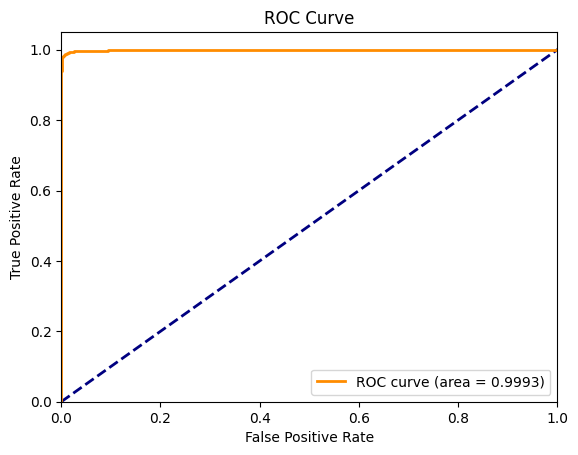

In [166]:
from sklearn.metrics import roc_auc_score, roc_curve


fpr, tpr, thresholds = roc_curve(y_true_avtp['label'], y_true_avtp['scores'])
aucroc = roc_auc_score(y_true_avtp['label'], y_true_avtp['scores'])
plt.figure()
plt.plot([0, 2], [0, 2], color="navy", lw=2, linestyle="--")
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {aucroc:.4f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()
plt.close()

In [167]:
get_overall_metrics(y_true_avtp['label'], y_true_avtp['y_pred'])

{'Accuracy': np.float64(0.9875414610468408),
 'TPR': np.float64(0.99038974906567),
 'FPR': np.float64(0.012967200610221205),
 'Precision': np.float64(0.9316926167754898),
 'F1-score': np.float64(0.960144927536232)}

# Sharp

In [41]:
from modeling.structure.factory import ModelingStructureFactory
from utils.get_device import get_device

device = get_device()
model = ModelingStructureFactory().get(config, logger, device)
model.compile()

/Users/mauriciosightman/Documents/Work/master/RABID/.venv/lib/python3.13/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [42]:
X_train, y_train = load_x(f'../data/tow-ids-dataset/processed/train_sliding-window_wsize_{config['pre_processing']['window_size']}_wstride_{config['pre_processing']['window_stride']}_n_58_{config['data_loader']['protocol_filter']}')
# X_train, y_train = load_x(f'../data/autoeth-intrusion-dataset/processed/train_sliding-window_wsize_32_wstride_15_n_58_AVTP')

In [43]:
X_test, y_test = load_x(f'../data/tow-ids-dataset/processed/test_sliding-window_wsize_{config['pre_processing']['window_size']}_wstride_{config['pre_processing']['window_stride']}_n_58_{config['data_loader']['protocol_filter']}')
# X_test, y_test = load_x(f'../data/autoeth-intrusion-dataset/processed/test_sliding-window_wsize_32_wstride_15_n_58_AVTP')

In [44]:
_, W, N = X_train.shape
X_train_flat = X_train.reshape(len(X_train), W * N)
X_test_flat  = X_test.reshape(len(X_test), W * N)

In [45]:
def score_no_reduction(X_flat):
    # X_flat: numpy array (batch, T*n_bytes)

    X_flat = torch.tensor(
        X_flat.reshape(W, N),
        dtype=torch.float32,
        device=device
    )

    X = X_flat.view(-1, W, N)

    x_in = X[:, :-1, :]
    x_true = X[:, 1:, :]

    with torch.no_grad():
        x_pred = model(x_in)

    error = (x_true - x_pred) ** 2

    return error.cpu().numpy()

In [46]:
background = X_train_flat[y_train['label'] == 'Normal'][:500]
background = torch.tensor(background, dtype=torch.float32).to(device)

In [47]:
import torch
import torch.nn as nn

class AnomalyScoreWrapper(nn.Module):
    def __init__(self, model, T, n_bytes):
        super().__init__()
        self.model = model
        self.T = T
        self.n_bytes = n_bytes

    def forward(self, X_flat):
        X = X_flat.view(-1, self.T, self.n_bytes)

        x_in = X[:, :-1, :]
        x_true = X[:, 1:, :]

        x_pred = self.model(x_in)

        error = (x_true - x_pred) ** 2
        score = error.sum(dim=(1, 2), keepdim=True)  # <-- FIX CRÍTICO

        return score


In [48]:
import shap

score_model = AnomalyScoreWrapper(model, W, N).to(device)
score_model.eval()

explainer = shap.GradientExplainer(
    score_model,
    background
)

In [49]:
y_test_scores = pd.concat([y_test, y_true[['scores']]], axis=1)

In [50]:
y_test['label'].value_counts()

label
PTP Sync    26570
Normal       6117
Name: count, dtype: int64

In [51]:
y_test_scores['attack_number'] = y_test_scores['desc_windows'].apply(lambda x: sum([0 if i == 'Normal' else 1 for i in x]))

In [52]:
y_test_scores['y_pred'] = y_test_scores['scores'].apply(lambda x: 0 if x <= threshold else 1)

In [53]:
idx_to_explain = y_test_scores[(y_test_scores['label'] == 'PTP Sync') & (y_test_scores['y_pred'] == 1)].index[:30]

X_explain = X_test_flat[idx_to_explain]
X_explain = torch.tensor(X_explain, dtype=torch.float32).to(device)

shap_values = explainer.shap_values(X_explain)

In [54]:
id = 0

shap_tb = shap_values.reshape(-1, W, N)

x_test_curr = X_test[idx_to_explain][id]
y_test_curr = y_test.iloc[idx_to_explain].iloc[id]

shap_packet = np.abs(shap_tb).sum(axis=2)[id]
shap_byte = np.abs(shap_tb).sum(axis=1)[id]

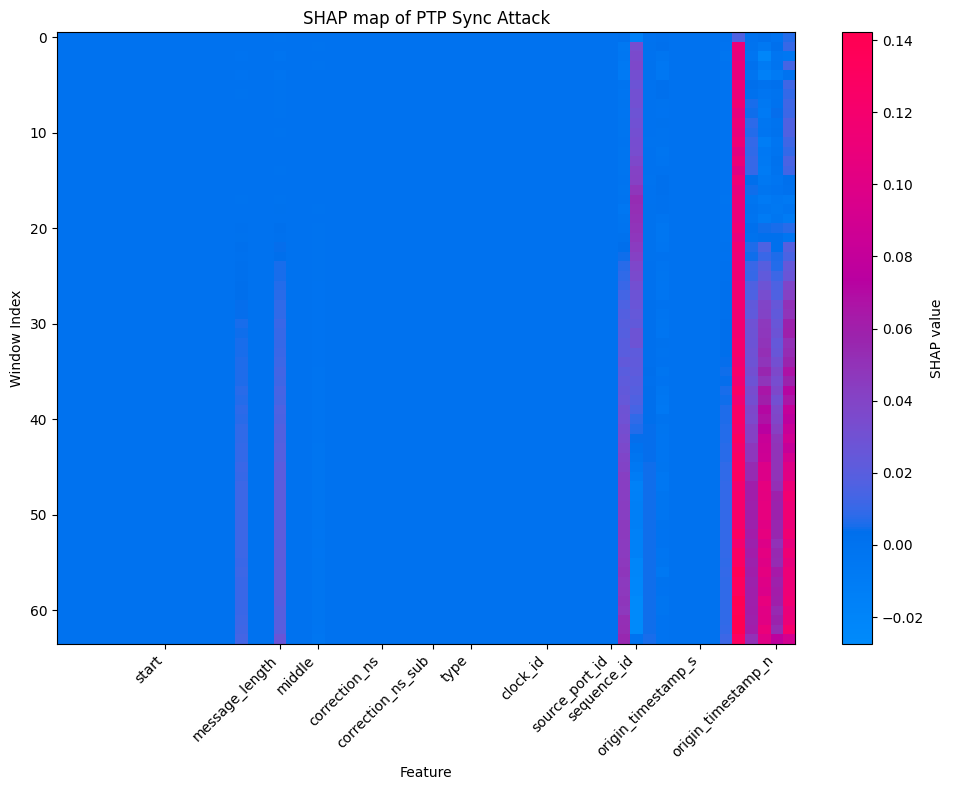

In [59]:
plot_img_loss(shap_tb.mean(0), title='SHAP map of PTP Sync Attack')

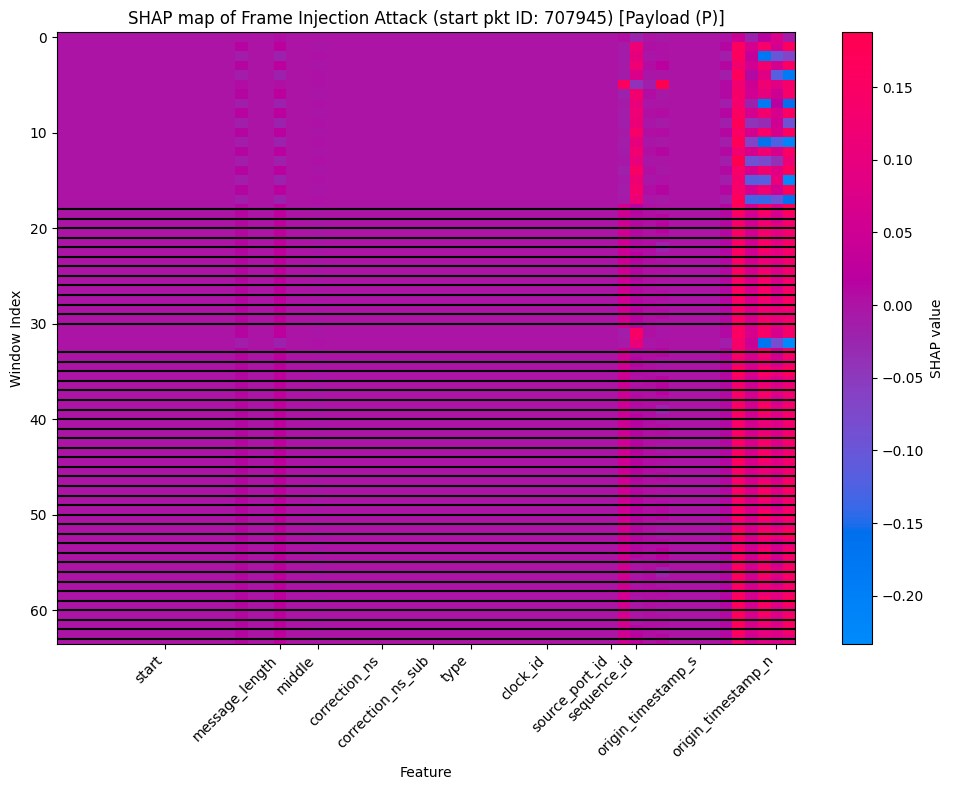

In [58]:
idx = -1
plot_img_loss(shap_tb[idx], 
              targets=y_test.iloc[idx_to_explain]['desc_windows'].iloc[idx], 
              title=f'SHAP map of Frame Injection Attack (start pkt ID: {y_test.iloc[idx_to_explain]['start_idx'].iloc[idx]}) [Payload (P)]')

NameError: name 'tau1' is not defined

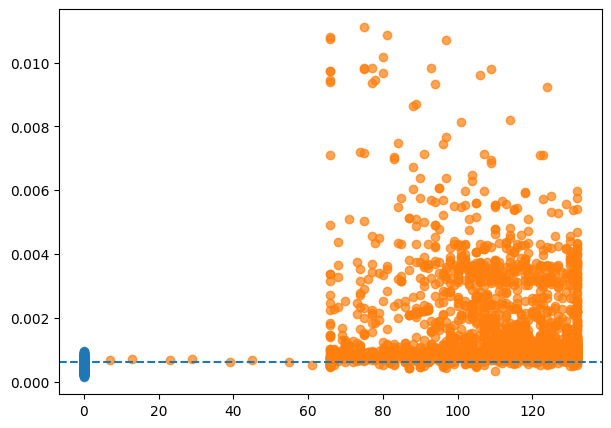

In [228]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

for lab in y_test_scores["label"].unique():
    subset = y_test_scores[y_test_scores["label"] == lab]
    plt.scatter(
        subset["attack_number"],
        subset["scores"],
        alpha=0.7,
        label=lab
    )

plt.axhline(
    threshold,
    linestyle="--",
    linewidth=1.5,
    label=f"Decision threshold"
)
plt.axhline(tau1, linestyle=":", c='orange', label="Uncertainty zone (k=1)")
plt.axhline(tau2, linestyle=":", c='orange')

plt.xlabel("Number of malicious packets in a Window")
plt.ylabel("Score")
plt.title("Relationship Between Attack Volume and Anomaly Score")
plt.legend(title="Class Label")

plt.tight_layout()
plt.show()

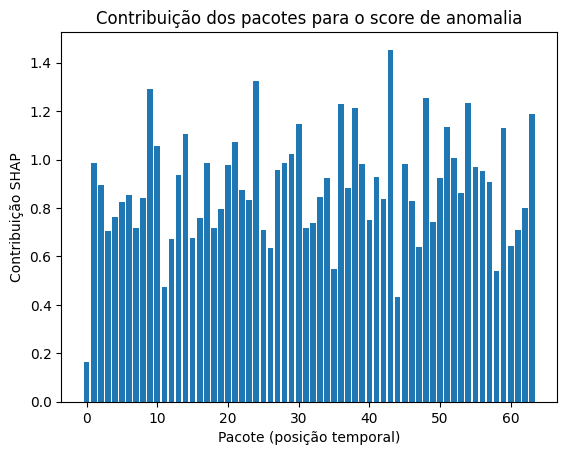

In [292]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(range(T), shap_packet)
plt.xlabel("Pacote (posição temporal)")
plt.ylabel("Contribuição SHAP")
plt.title("Contribuição dos pacotes para o score de anomalia")
plt.show()

In [293]:
RED = "\033[31m"
RESET = "\033[0m"

for i in range(1, len(y_test_curr['desc_windows'])):
    label = y_test_curr['desc_windows'][i]
    pkt_loss = score_no_reduction(x_test_curr)[0].sum(axis=1)
    if label == 'Normal':
        print(f'{y_test_curr['desc_windows'][i]} \t\t\t-> {shap_packet[i]:.2f} ({pkt_loss[i-1]:.2f})')
    elif 'CAN' in label:
        print(f'{RED}{y_test_curr['desc_windows'][i]} \t\t-> {shap_packet[i]:.2f} ({pkt_loss[i-1]:.2f}){RESET}')
    else:
        print(f'{RED}{y_test_curr['desc_windows'][i]} \t-> {shap_packet[i]:.2f} ({pkt_loss[i-1]:.2f}){RESET}')

Normal 			-> 0.98 (1.51)
Normal 			-> 0.89 (2.33)
Normal 			-> 0.70 (2.17)
Normal 			-> 0.76 (1.69)
Normal 			-> 0.82 (1.79)
Normal 			-> 0.85 (0.97)
Normal 			-> 0.72 (1.59)
Normal 			-> 0.84 (1.02)
Normal 			-> 1.29 (1.67)
CAN Replay 		-> 1.06 (2.65)
Normal 			-> 0.47 (1.38)
CAN Replay 		-> 0.67 (1.93)
Normal 			-> 0.94 (2.01)
CAN Replay 		-> 1.11 (1.52)
Normal 			-> 0.68 (1.61)
Normal 			-> 0.76 (2.28)
CAN Replay 		-> 0.99 (2.52)
Normal 			-> 0.72 (1.95)
Normal 			-> 0.80 (1.27)
Normal 			-> 0.98 (2.33)
CAN Replay 		-> 1.07 (2.39)
Normal 			-> 0.87 (2.22)
Normal 			-> 0.83 (1.39)
CAN Replay 		-> 1.33 (1.41)
Normal 			-> 0.71 (1.36)
Normal 			-> 0.64 (1.85)
CAN Replay 		-> 0.96 (1.67)
Normal 			-> 0.99 (1.69)
CAN Replay 		-> 1.02 (2.17)
Normal 			-> 1.15 (1.14)
Normal 			-> 0.72 (2.08)
Normal 			-> 0.74 (2.32)
CAN Replay 		-> 0.84 (1.50)
CAN Replay 		-> 0.93 (2.20)
Normal 			-> 0.55 (1.35)
CAN Replay 		-> 1.23 (1.66)
Normal 			-> 0.88 (2.37)
CAN Replay 		-> 1.21 (2.01)
Normal 			-> 0

In [294]:
df_pkt = []
shap_tb_flatten = np.abs(shap_tb).sum(axis=2)
for j in range(len(idx_to_explain)):

    x = X_test[idx_to_explain][j]
    y = y_test.iloc[idx_to_explain].iloc[j]

    for i in range(1, len(y['desc_windows'])):
        
        pkt_loss = score_no_reduction(x)[0].sum(axis=1)
        df_pkt.append({
            'pkt': j,
            'label': y['desc_windows'][i],
            'shap_value': shap_tb_flatten[j][i],
            'pkt_loss': pkt_loss[i-1]
        })

In [295]:
df_pkt = pd.DataFrame(df_pkt)
df_pkt = df_pkt.round(2)

In [296]:
df_pkt.groupby('label').agg(shap_min=('shap_value', 'min'), shap_max=('shap_value', 'max'), shap_mean=('shap_value', 'mean'),
                            pkt_loss_min=('pkt_loss', 'min'), pkt_loss_max=('pkt_loss', 'max'), pkt_loss_mean=('pkt_loss', 'mean'))

,shap_min,shap_max,shap_mean,pkt_loss_min,pkt_loss_max,pkt_loss_mean
label,,,,,,
CAN Replay,0.54,1.46,0.978721,1.30,2.81,1.950874
Normal,0.42,1.45,0.823350,0.94,2.75,1.721542


In [227]:
plot_img_loss(score_no_reduction(x_test_curr)[0], targets=y_test_curr['desc_windows'][1:], name='Mapa SHAP por byte e pacote', shap=shap_packet[1:])

TypeError: plot_img_loss() got an unexpected keyword argument 'shap'

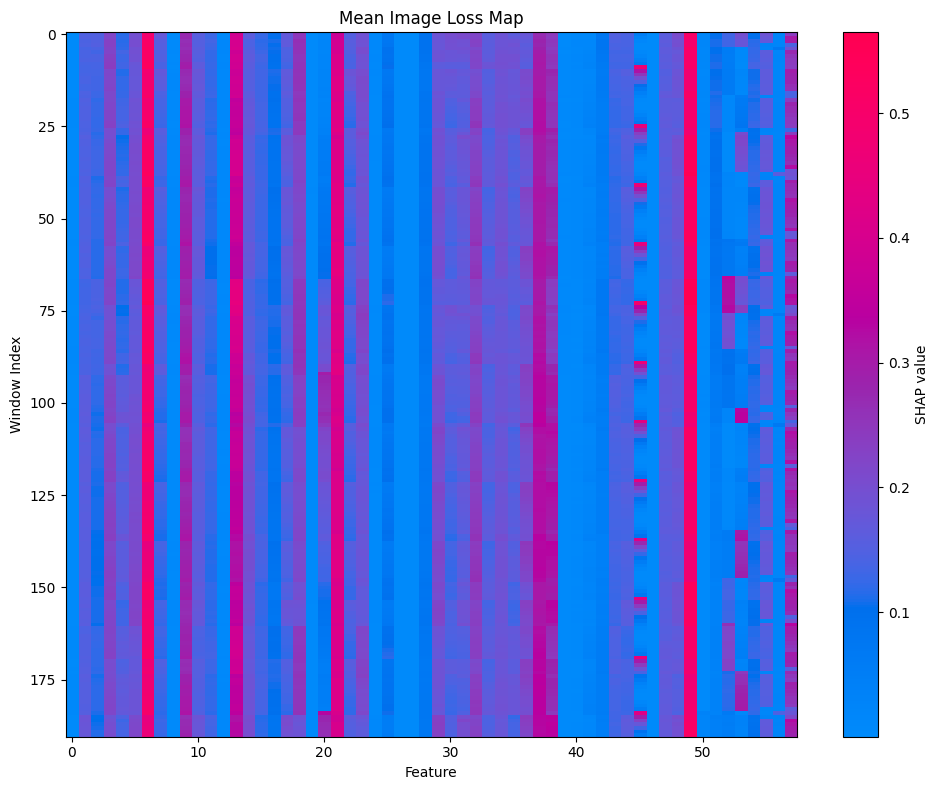

In [229]:
plot_img_loss(score_no_reduction(x_test_curr)[0])

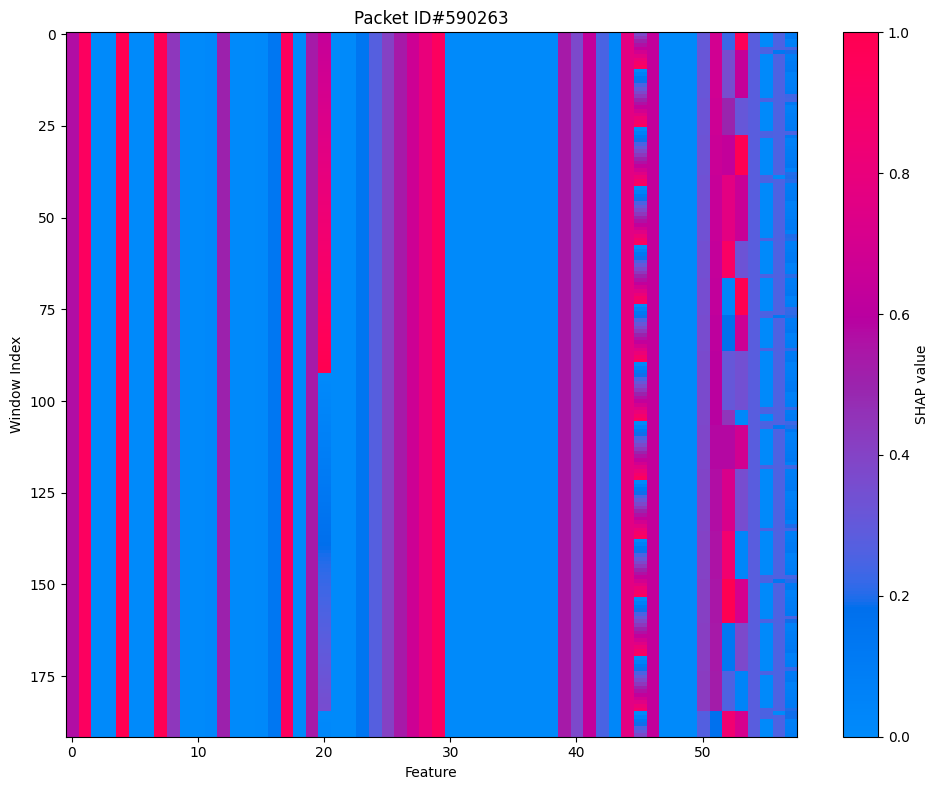

In [226]:
plot_img_loss(x_test_curr.reshape(W, N), name=f'Packet ID#{y_test_curr['start_idx']}')